<a href="https://colab.research.google.com/github/SubhanaJamil/Phylogenetic-Analysis/blob/main/Kinesin_Motor_Proteins_Auspice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install biopython
!apt-get install -qq -y mafft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 108.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [biopython]


In [11]:
!wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O miniforge.sh
!bash miniforge.sh -b -p /usr/local/miniforge
import os
os.environ["PATH"] = "/usr/local/miniforge/bin:" + os.environ["PATH"]

!conda install -c bioconda raxml-ng modeltest-ng -y

ERROR: File or directory already exists: '/usr/local/miniforge'
If you want to update an existing installation, use the -u option.
Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: - \ | done

# All requested packages already installed.



In [12]:
from Bio import SeqIO, Entrez

Entrez.email = "your_email@example.com"

handle = Entrez.efetch(db="protein", rettype="fasta", id="1CZ7_A")
sequence = SeqIO.read(handle, "fasta")

with open("kinesin14_query.fasta", "w") as f:
    SeqIO.write(sequence, f, "fasta")

handle.close()

print("Sequence retrieved:", sequence.id)
print("Length:", len(sequence.seq))

Sequence retrieved: pdb|1CZ7|A
Length: 406


In [13]:
from Bio.Blast import NCBIWWW

result_handle = NCBIWWW.qblast(
    "blastp",
    "pdb",
    sequence.seq
)

print("BLAST search completed.")

BLAST search completed.


In [14]:
from Bio.Blast import NCBIXML

blast_record = NCBIXML.read(result_handle)
result_handle.close()

print("Hits found:", len(blast_record.alignments))

Hits found: 50


In [22]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO # Import SeqIO for writing

# Prepare sequences for MAFFT, using a dictionary to store unique sequences by ID
sequences_to_align_dict = {}

# Add the query sequence first
sequences_to_align_dict[sequence.id] = sequence

# Extract subject sequences from BLAST alignments
for alignment in blast_record.alignments:
    if alignment.hsps: # Ensure there's at least one HSP for a subject sequence
        # Use the hit_id for uniqueness and the subject sequence from the first HSP
        hit_id = alignment.hit_id
        hit_seq_record = SeqRecord(Seq(alignment.hsps[0].sbjct), id=hit_id, description=alignment.title)

        # Add to dictionary. If an ID already exists, it will be overwritten,
        # which ensures uniqueness by ID. The query sequence might be overwritten
        # by its BLAST hit counterpart if IDs match, which is fine.
        sequences_to_align_dict[hit_id] = hit_seq_record

# Convert dictionary values (unique sequences) to a list
sequences_to_align = list(sequences_to_align_dict.values())

# Write all unique sequences to a new FASTA file for MAFFT
with open("kinesin14_sequences.fasta", "w") as output_handle:
    SeqIO.write(sequences_to_align, output_handle, "fasta")

print(f"Created kinesin14_sequences.fasta with {len(sequences_to_align)} unique sequences.")

Created kinesin14_sequences.fasta with 50 unique sequences.


In [24]:
!mafft kinesin14_sequences.fasta > aligned_kinesin14.fasta

print("Alignment completed.")

nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8192 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
    1 / 50
done.

Constructing a UPGMA tree (efffree=0) ... 
   40 / 50
done.

Progressive alignment 1/2... 
STEP    42 / 49  f
Reallocating..done. *alloclen = 1839
STEP    49 / 49  f
done.

Making a distance matrix from msa.. 
    0 / 50
done.

Constructing a UPGMA tree (efffree=1) ... 
   40 / 50
done.

Progressive alignment 2/2... 
STEP    45 / 49  f
Reallocating..done. *alloclen = 1841
STEP    49 / 49  f
done.

disttbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It

In [25]:
from Bio import AlignIO

alignment = AlignIO.read("aligned_kinesin14.fasta", "fasta")

print("Alignment length:", alignment.get_alignment_length())
print("Number of sequences:", len(alignment))

Alignment length: 506
Number of sequences: 50


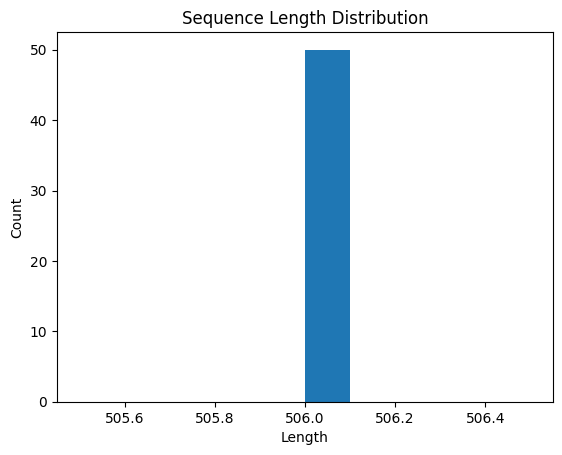

In [26]:
import matplotlib.pyplot as plt

lengths = [len(rec.seq) for rec in alignment]

plt.figure()
plt.hist(lengths)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [27]:
!raxml-ng \
--msa aligned_kinesin14.fasta \
--model LG+I+G4 \
--prefix K14_TREE \
--threads 2


RAxML-NG v. 2.0.1 released on 24.04.2026 by The Exelixis Lab.
Developed by: Oleksiy M. Kozlov and Alexandros Stamatakis.
Contributors: Diego Darriba, Tomas Flouri, Benoit Morel, Sarah Lutteropp, Ben Bettisworth,
              Julia Haag, Anastasis Togkousidis, Julius Wiegert, Christoph Stelz.
Latest version: https://github.com/amkozlov/raxml-ng
Questions/problems/suggestions? Please visit: https://groups.google.com/forum/#!forum/raxml

System: Intel(R) Xeon(R) CPU @ 2.20GHz, 1 cores, 12 GB RAM

RAxML-NG was called at 16-May-2026 20:37:59 as follows:

raxml-ng --msa aligned_kinesin14.fasta --model LG+I+G4 --prefix K14_TREE --threads 2

Analysis options:
  run mode: ML tree search (adaptive)
  start tree(s): adaptive
  random seed: 1778963879
  tip-inner: OFF
  pattern compression: ON
  per-rate scalers: OFF
  site repeats: ON
  logLH epsilon: general: 10.000000, brlen-triplet: 1000.000000
  stopping rule: OFF
  fast spr radius: AUTO
  spr subtree cutoff: 1.000000
  fast CLV updates: ON

<Figure size 1000x600 with 0 Axes>

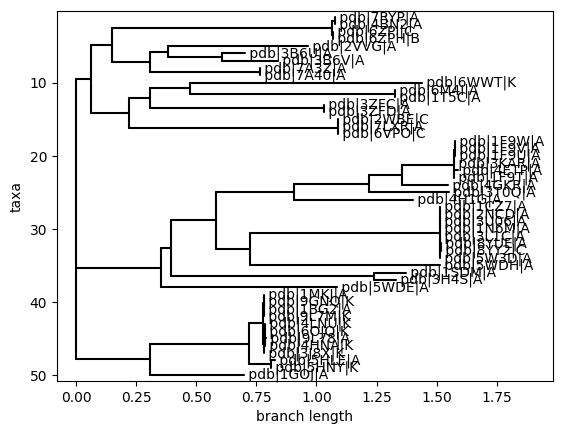

In [28]:
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read("K14_TREE.raxml.bestTree", "newick")

plt.figure(figsize=(10, 6))
Phylo.draw(tree)
plt.show()

In [ ]:
!raxml-ng \
--bootstrap \
--msa aligned_kinesin14.fasta \
--model LG+I+G4 \
--bs-trees 100 \
--prefix K14_BOOT

print("Bootstrap analysis completed.")


RAxML-NG v. 2.0.1 released on 24.04.2026 by The Exelixis Lab.
Developed by: Oleksiy M. Kozlov and Alexandros Stamatakis.
Contributors: Diego Darriba, Tomas Flouri, Benoit Morel, Sarah Lutteropp, Ben Bettisworth,
              Julia Haag, Anastasis Togkousidis, Julius Wiegert, Christoph Stelz.
Latest version: https://github.com/amkozlov/raxml-ng
Questions/problems/suggestions? Please visit: https://groups.google.com/forum/#!forum/raxml

System: Intel(R) Xeon(R) CPU @ 2.20GHz, 1 cores, 12 GB RAM

RAxML-NG was called at 16-May-2026 20:40:40 as follows:

raxml-ng --bootstrap --msa aligned_kinesin14.fasta --model LG+I+G4 --bs-trees 100 --prefix K14_BOOT

Analysis options:
  run mode: Bootstrapping (adaptive) (Felsenstein Bootstrap)
  start tree(s): 
  bootstrap replicates: parsimony (100)
  random seed: 1778964040
  tip-inner: OFF
  pattern compression: ON
  per-rate scalers: OFF
  site repeats: ON
  logLH epsilon: general: 10.000000, brlen-triplet: 1000.000000
  stopping rule: OFF
  fast 